# charge bibliotique

In [455]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

# Charger les variables d'environnement

In [456]:
load_dotenv()

DATABASE_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:"
    f"{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:"
    f"{os.getenv('DB_PORT')}/"
    f"{os.getenv('DB_NAME')}"
)
engine = create_engine(DATABASE_URL)
print("connexion oui")

connexion oui


Lire les données depuis le schéma staging

In [457]:
df = pd.read_sql(
    "SELECT * FROM staging.products_raw",
    engine
)
print("Nombre de lignes avant nettoyage :", len(df))

Nombre de lignes avant nettoyage : 2004


# Nettoyage


 Nettoyage des colonnes de prix et de pourcentage

In [458]:
# Prix
df["new_price"] = (
    df["new_price"]
    .str.replace("EGP", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["old_price"] = (
    df["old_price"]
    .str.replace("EGP", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
# Réduction
df["percent_discount"] = (
    df["percent_discount"]
    .str.replace("%", "", regex=False)
    .str.strip()
)
# Score vendeur
df["saler_score"] = (
    df["saler_score"]
    .str.replace("%", "", regex=False)
    .str.strip()
)

supprimer doubblons

In [459]:
df = df.drop_duplicates() 

Conversion des colonnes numériques

In [460]:
numeric_columns = [
    "new_price",
    "old_price",
    "percent_discount",
    "rate",
    "verified_ratings",
    "saler_score",
    "Followers"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Remplacer les valeurs manquantes

In [462]:
df=df.fillna({
    "new_price":df["new_price"].median(),
    "old_price":df["old_price"].median(),
    "rate":df["rate"].median(),
    "verified_ratings":df["verified_ratings"].median(),
    "percent_discount":df["percent_discount"].median(),
    "saler_score":df["saler_score"].median(),
    "Followers":df["Followers"].median()
})
df=df.fillna({
    "name":df["name"].mode()[0],
    "Order Fulfillment_Rate":df["Order Fulfillment_Rate"].mode()[0],
    "Quality Score":df["Quality Score"].mode()[0],
    "Customer Rating":df["Customer Rating"].mode()[0],
})

Les Outliers

visualiser les valeurs aberrantes (outliers) de chaque colonne numérique à l'aide d'un boxplot

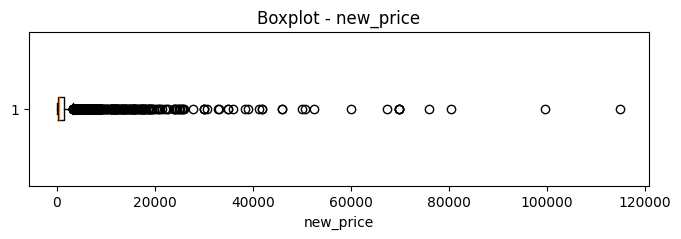

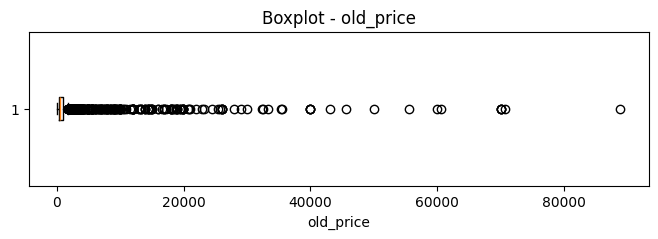

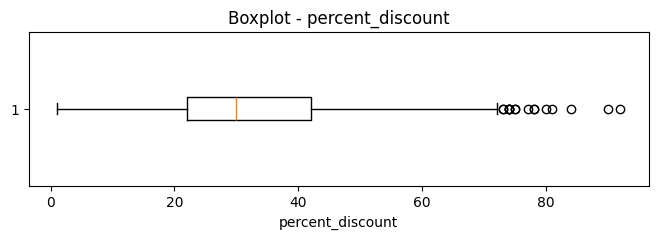

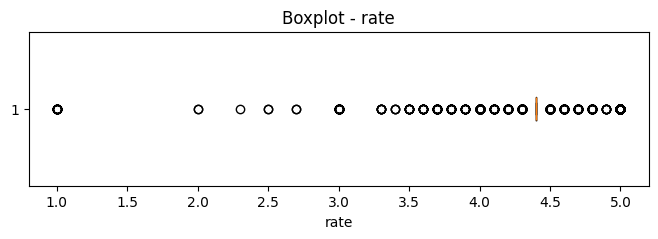

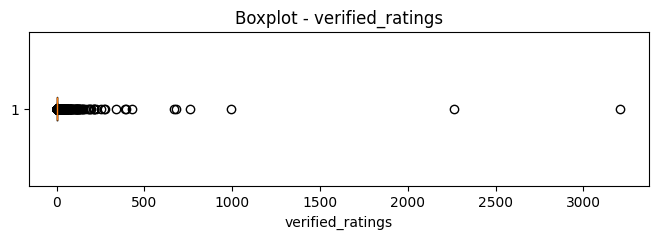

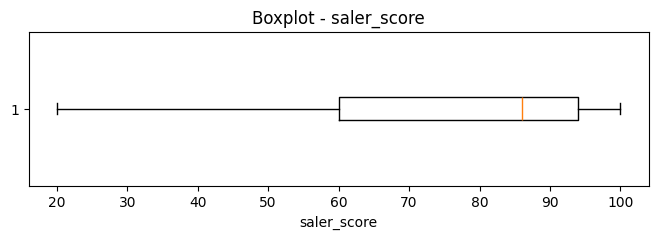

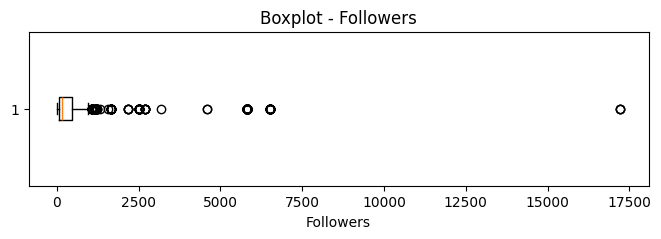

In [464]:
for col in numeric_columns:

    plt.figure(figsize=(8,2))
    plt.boxplot(df[col].dropna(), vert=False)

    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)

    plt.show()

applique fonction outlier

In [465]:
from fonction_outlier import *
numeric_columns = [
    "new_price",
    "old_price",
    "percent_discount",
    "rate",
    "verified_ratings",
    "saler_score",
    "Followers"
]

for col in numeric_columns:
    df = remove_outliers(df, col)


# Feature Engineering

In [466]:
#montant de la réduction
df["discount_amount"] = df["old_price"] - df["new_price"]
#produit en promotion
df["is_discounted"] = df["percent_discount"].apply(
    lambda x: "Yes" if x > 0 else "No"
)
#applique fonction_feauture_engineering
import importlib
import fonction_feauture_engineering as fe
importlib.reload(fe)
df["price_category"] = df["new_price"].apply(fe.price_category)
df["popularity"] = df["verified_ratings"].apply(fe.popularity)
df["seller_level"] = df["saler_score"].apply(fe.seller_level)

Chargement des données nettoyées dans PostgreSQL

In [467]:
# Création du schéma clean
with engine.connect() as conn:
    conn.execute(text("CREATE SCHEMA IF NOT EXISTS clean"))
    conn.commit()

# Chargement des données nettoyées
df.to_sql(
    name="products_clean",
    con=engine,
    schema="clean",
    if_exists="replace",   # replace ou append
    index=False
)

print("Données nettoyées chargées dans le schéma clean.")

Données nettoyées chargées dans le schéma clean.
